In [1]:
import subprocess
subprocess.run(['pip', 'install', 'yfinance', 'openpyxl'])

CompletedProcess(args=['pip', 'install', 'yfinance', 'openpyxl'], returncode=0)

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# 10 Indian stocks — sector wise
stocks = {
    # IT Sector
    'TCS': 'TCS.NS',
    'Infosys': 'INFY.NS',
    'Wipro': 'WIPRO.NS',
    
    # Banking Sector
    'HDFC Bank': 'HDFCBANK.NS',
    'ICICI Bank': 'ICICIBANK.NS',
    
    # Energy Sector
    'Reliance': 'RELIANCE.NS',
    'ONGC': 'ONGC.NS',
    
    # Auto Sector
    'Tata Motors': 'TATAMOTORS.NS',
    'Maruti': 'MARUTI.NS',
    
    # FMCG Sector
    'HUL': 'HINDUNILVR.NS',
}

# 5 saal ka data
start_date = '2020-01-01'
end_date = '2025-01-01'

# Khali dictionary
all_data = {}

# Har stock ka data fetch karo
for company, ticker in stocks.items():
    print(f"Fetching {company} data...")
    all_data[company] = yf.download(ticker, start=start_date, end=end_date)
    print(f"{company}: {len(all_data[company])} rows fetched ✅")

print("\nAll 10 stocks data fetched successfully! 🎉")

Fetching TCS data...


[*********************100%***********************]  1 of 1 completed


TCS: 1238 rows fetched ✅
Fetching Infosys data...


[*********************100%***********************]  1 of 1 completed


Infosys: 1238 rows fetched ✅
Fetching Wipro data...


...

Tata Motors: 0 rows fetched ✅
Fetching Maruti data...


[*********************100%***********************]  1 of 1 completed


Maruti: 1238 rows fetched ✅
Fetching HUL data...


[*********************100%***********************]  1 of 1 completed

HUL: 1238 rows fetched ✅

All 10 stocks data fetched successfully! 🎉


In [4]:
# Ek company ka data 
print("Reliance ka data:")
print(all_data['Reliance'].head())

print("\nColumns:")
print(all_data['Reliance'].columns.tolist())

print("\nShape:")
print(all_data['Reliance'].shape)

Reliance ka data:
Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
2020-01-01  675.324158  683.152852  673.490062  679.081936    14004468
2020-01-02  686.821228  689.348791  676.397899  676.397899    17710316
2020-01-03  687.648865  689.661956  681.318790  685.792313    20984698
2020-01-06  671.700684  683.510767  670.134933  679.976719    24519177
2020-01-07  682.034485  686.463273  677.068828  679.529260    16683622

Columns:
[('Close', 'RELIANCE.NS'), ('High', 'RELIANCE.NS'), ('Low', 'RELIANCE.NS'), ('Open', 'RELIANCE.NS'), ('Volume', 'RELIANCE.NS')]

Shape:
(1238, 5)


In [5]:
# Saare stocks ki closing price ek DataFrame mein
closing_prices = pd.DataFrame()

for company, data in all_data.items():
    closing_prices[company] = data['Close']

print(closing_prices.head())
print(f"\nShape: {closing_prices.shape}")

                    TCS     Infosys       Wipro   HDFC Bank  ICICI Bank  \
2020-01-01  1841.149780  633.151123  113.709183  605.529358  519.137878   
2020-01-02  1832.697998  631.303711  113.984619  609.389099  522.861572   
2020-01-03  1869.222168  641.013489  115.269989  600.698792  521.169006   
2020-01-06  1869.052002  634.869629  115.751991  587.698792  508.450531   
2020-01-07  1873.639404  625.460693  117.152122  597.004761  505.742371   

              Reliance       ONGC  Tata Motors       Maruti          HUL  
2020-01-01  675.324158  85.371384          NaN  6945.335449  1749.931396  
2020-01-02  686.821228  85.773293          NaN  6962.575195  1751.286865  
2020-01-03  687.648865  86.041222          NaN  6890.763672  1741.708130  
2020-01-06  671.700684  84.567589          NaN  6689.528809  1730.864746  
2020-01-07  682.034485  84.232658          NaN  6719.165527  1735.608887  

Shape: (1238, 10)


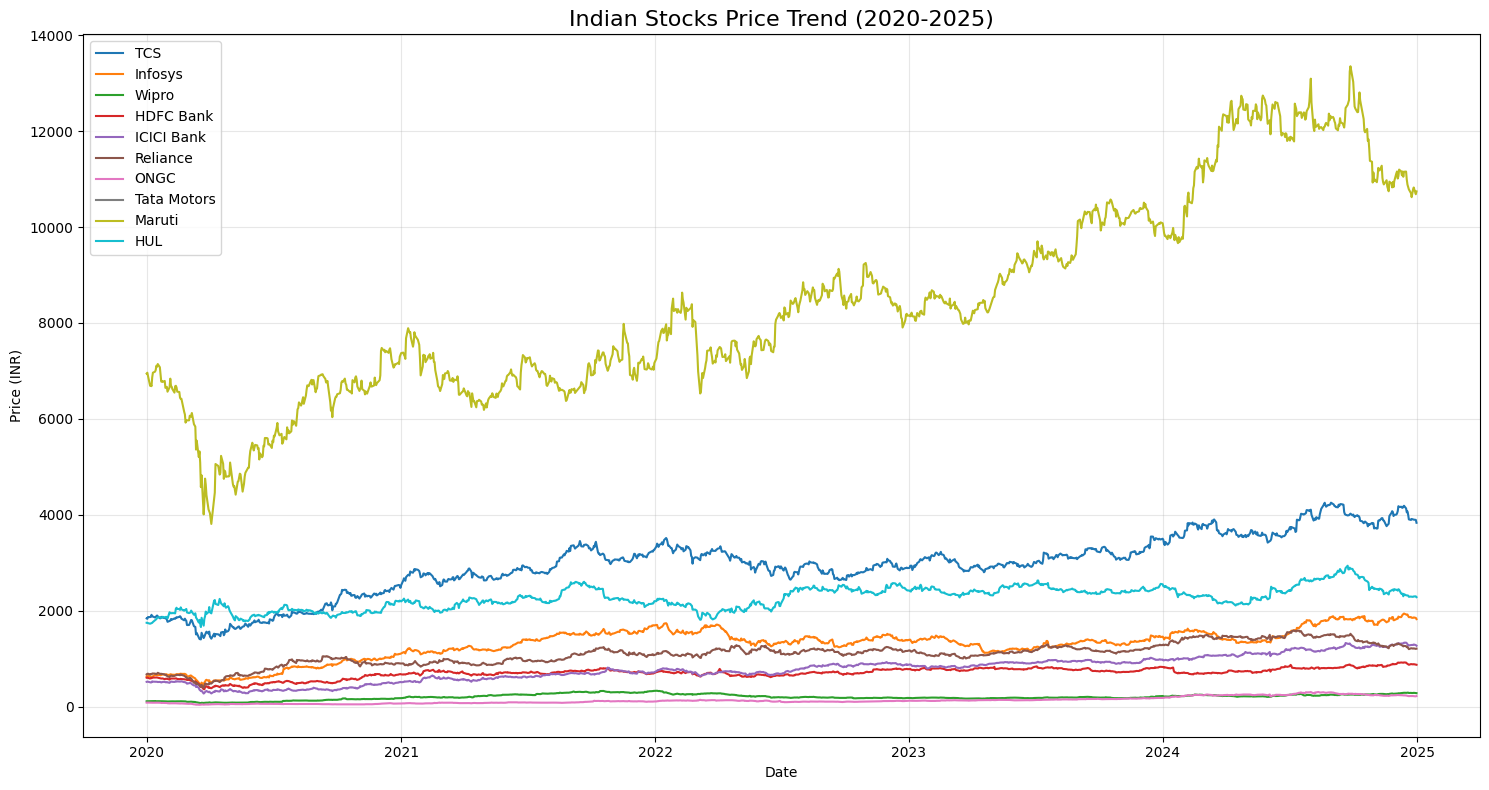

In [6]:
# Saare stocks ka price trend
plt.figure(figsize=(15, 8))

for company in closing_prices.columns:
    plt.plot(closing_prices.index, closing_prices[company], label=company)

plt.title('Indian Stocks Price Trend (2020-2025)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_price_trend.png', dpi=150)
plt.show()

In [7]:
# Daily returns calculate 
daily_returns = closing_prices.pct_change()

# Overall return calculate (2020 se 2025 tak)
total_returns = ((closing_prices.iloc[-1] - closing_prices.iloc[0]) / closing_prices.iloc[0]) * 100

print("Total return of stocks in 5 years(%):")
print(total_returns.sort_values(ascending=False).round(2))

Total return of stocks in 5 years(%):
Infosys        188.39
ONGC           160.67
Wipro          148.84
ICICI Bank     144.99
TCS            108.27
Reliance        79.26
Maruti          54.67
HDFC Bank       44.44
HUL             30.56
Tata Motors       NaN
dtype: float64


In [8]:
# Missing values fix 
closing_prices = closing_prices.ffill()

total_returns = ((closing_prices.iloc[-1] - closing_prices.iloc[0]) / closing_prices.iloc[0]) * 100

print("5 saal mein har stock ka total return (%):")
print(total_returns.sort_values(ascending=False).round(2))

5 saal mein har stock ka total return (%):
Infosys        188.39
ONGC           160.67
Wipro          148.84
ICICI Bank     144.99
TCS            108.27
Reliance        79.26
Maruti          54.67
HDFC Bank       44.44
HUL             30.56
Tata Motors       NaN
dtype: float64


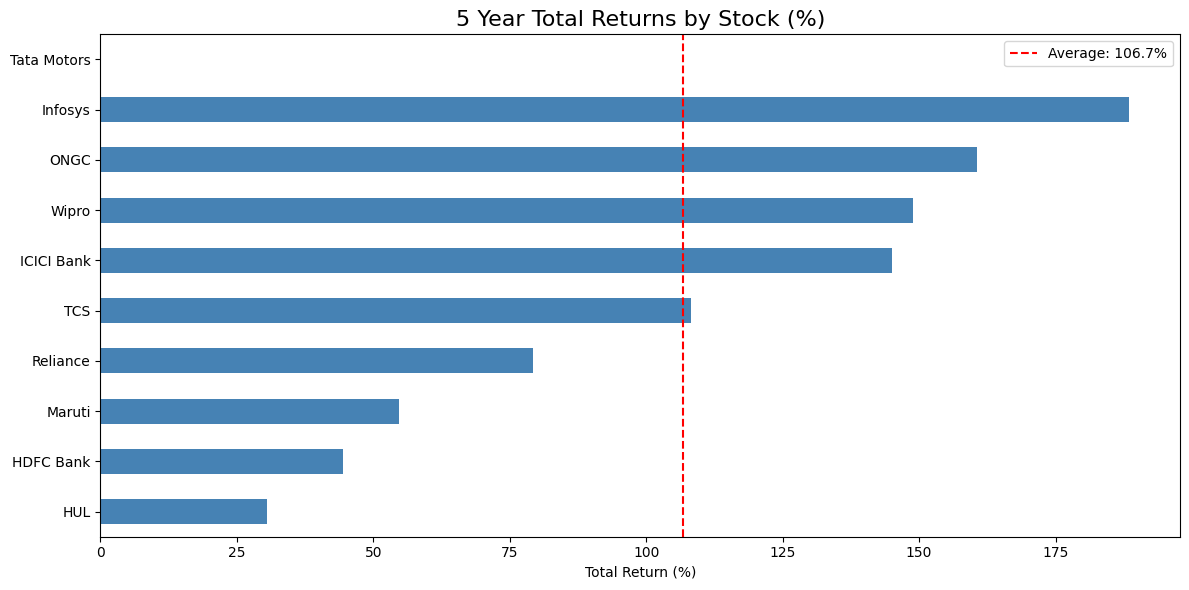

In [9]:
plt.figure(figsize=(12, 6))
total_returns.sort_values().plot(kind='barh', color='steelblue')
plt.title('5 Year Total Returns by Stock (%)', fontsize=16)
plt.xlabel('Total Return (%)')

avg = total_returns.mean()
plt.axvline(x=avg, color='red', linestyle='--', label=f'Average: {avg:.1f}%')
plt.legend()

plt.tight_layout()
plt.savefig('total_returns.png', dpi=150)
plt.show() 

In [10]:
# Volatility calculate
volatility = daily_returns.std() * 100

print("Volatility of stocks %:")
print(volatility.sort_values(ascending=False).round(2))

Volatility of stocks %:
ONGC           2.43
ICICI Bank     2.00
Maruti         1.89
Reliance       1.87
Wipro          1.84
Infosys        1.75
HDFC Bank      1.72
TCS            1.54
HUL            1.51
Tata Motors     NaN
dtype: float64


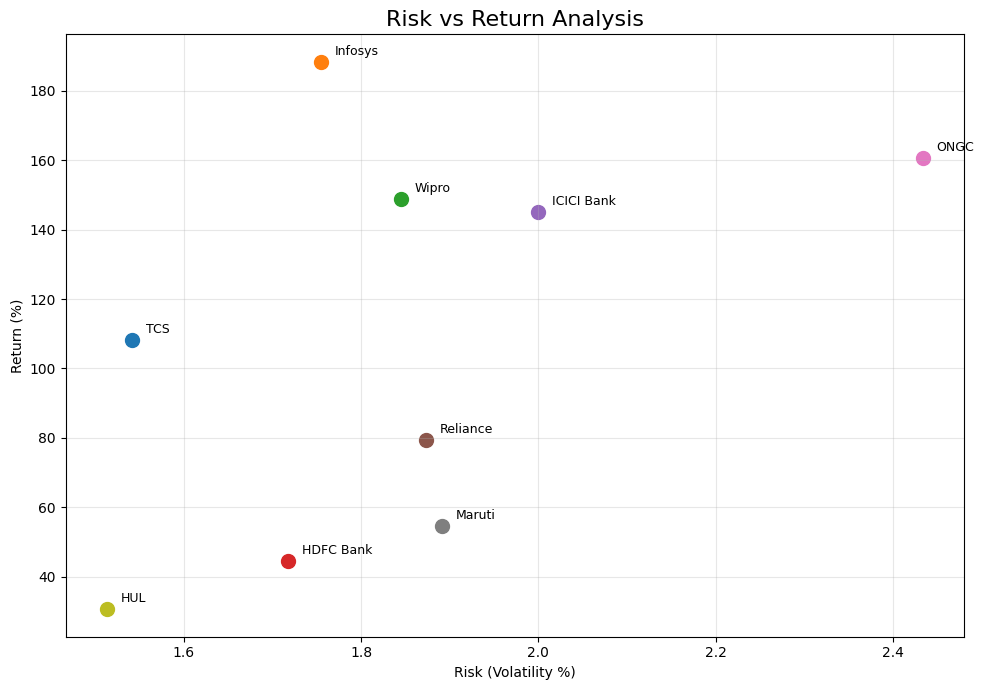

In [11]:
plt.figure(figsize=(10, 7))

for company in total_returns.index:
    if company != 'Tata Motors':
        plt.scatter(volatility[company], total_returns[company], s=100)
        plt.annotate(company, 
                    (volatility[company], total_returns[company]),
                    textcoords="offset points",
                    xytext=(10, 5),
                    fontsize=9)

plt.title('Risk vs Return Analysis', fontsize=16)
plt.xlabel('Risk (Volatility %)')
plt.ylabel('Return (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('risk_vs_return.png', dpi=150)
plt.show()

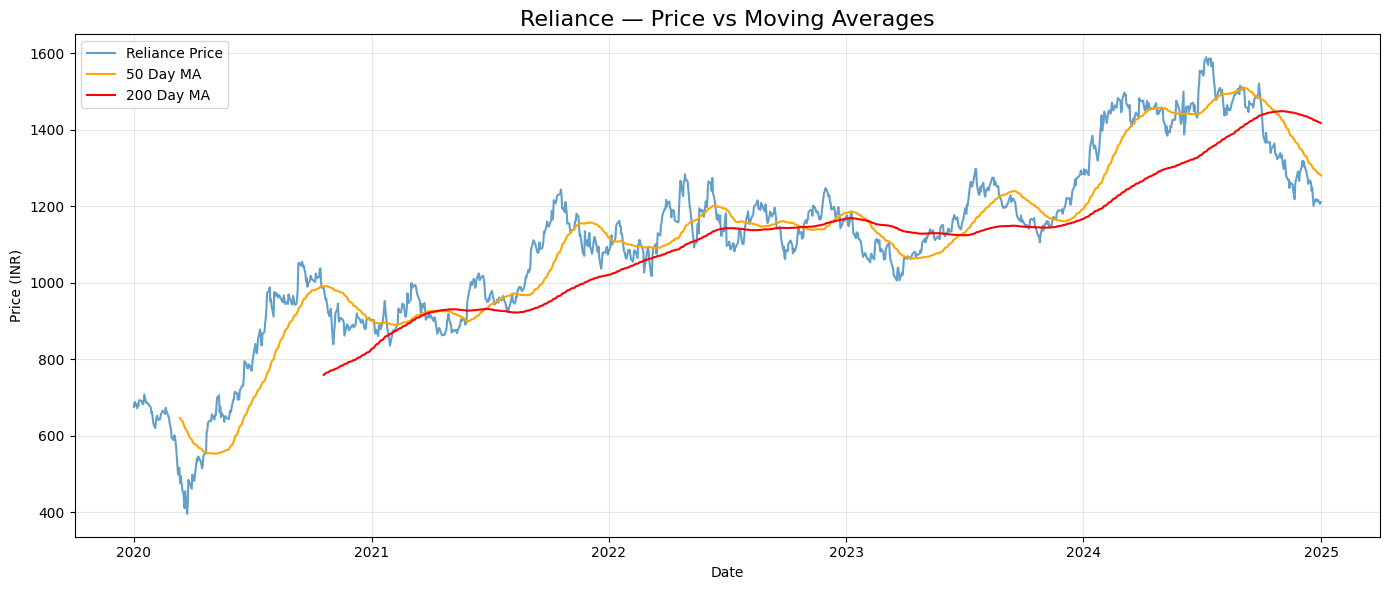

In [12]:
# Reliance ka 50 day aur 200 day moving average
reliance = closing_prices['Reliance']

ma50 = reliance.rolling(window=50).mean()
ma200 = reliance.rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(reliance.index, reliance, label='Reliance Price', alpha=0.7)
plt.plot(reliance.index, ma50, label='50 Day MA', color='orange')
plt.plot(reliance.index, ma200, label='200 Day MA', color='red')
plt.title('Reliance — Price vs Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('moving_average.png', dpi=150)
plt.show()

In [13]:
# Excel file export
with pd.ExcelWriter('stock_data.xlsx', engine='openpyxl') as writer:

    closing_prices.to_excel(writer, sheet_name='Closing Prices')

    total_returns.to_frame('Total Return %').to_excel(writer, sheet_name='Total Returns')
    
    volatility.to_frame('Volatility %').to_excel(writer, sheet_name='Volatility')

print("Excel file saved successfully!")

Excel file saved successfully!


In [14]:

total_returns_df = total_returns.to_frame('Total Return %')
total_returns_df.index.name = 'Company'

volatility_df = volatility.to_frame('Volatility %')
volatility_df.index.name = 'Company'

with pd.ExcelWriter('stock_data.xlsx', engine='openpyxl') as writer:
    closing_prices.to_excel(writer, sheet_name='Closing Prices')
    total_returns_df.to_excel(writer, sheet_name='Total Returns')
    volatility_df.to_excel(writer, sheet_name='Volatility')

print("Excel file updated!")

Excel file updated!


In [15]:
# Adding Sector information
sector_data = {
    'Company': ['TCS', 'Infosys', 'Wipro', 'HDFC Bank', 'ICICI Bank', 
                'Reliance', 'ONGC', 'Maruti', 'HUL'],
    'Sector': ['IT', 'IT', 'IT', 'Banking', 'Banking', 
               'Energy', 'Energy', 'Auto', 'FMCG'],
    'Total Return %': [total_returns['TCS'], total_returns['Infosys'], 
                       total_returns['Wipro'], total_returns['HDFC Bank'],
                       total_returns['ICICI Bank'], total_returns['Reliance'],
                       total_returns['ONGC'], total_returns['Maruti'],
                       total_returns['HUL']],
    'Volatility %': [volatility['TCS'], volatility['Infosys'],
                     volatility['Wipro'], volatility['HDFC Bank'],
                     volatility['ICICI Bank'], volatility['Reliance'],
                     volatility['ONGC'], volatility['Maruti'],
                     volatility['HUL']]
}

sector_df = pd.DataFrame(sector_data)

#Adding in excel 
with pd.ExcelWriter('stock_data.xlsx', engine='openpyxl') as writer:
    closing_prices.to_excel(writer, sheet_name='Closing Prices')
    total_returns_df.to_excel(writer, sheet_name='Total Returns')
    volatility_df.to_excel(writer, sheet_name='Volatility')
    sector_df.to_excel(writer, sheet_name='Sector Analysis', index=False)

print("Sector data added!")

Sector data added!


In [16]:
# Date column fix 
closing_prices_reset = closing_prices.reset_index()
closing_prices_reset.columns.name = None
closing_prices_reset = closing_prices_reset.rename(columns={'Date': 'Date'})

print(closing_prices_reset.head())
print(closing_prices_reset.dtypes)


       index          TCS     Infosys       Wipro   HDFC Bank  ICICI Bank  \
0 2020-01-01  1841.149780  633.151123  113.709183  605.529358  519.137878   
1 2020-01-02  1832.697998  631.303711  113.984619  609.389099  522.861572   
2 2020-01-03  1869.222168  641.013489  115.269989  600.698792  521.169006   
3 2020-01-06  1869.052002  634.869629  115.751991  587.698792  508.450531   
4 2020-01-07  1873.639404  625.460693  117.152122  597.004761  505.742371   

     Reliance       ONGC  Tata Motors       Maruti          HUL  
0  675.324158  85.371384          NaN  6945.335449  1749.931396  
1  686.821228  85.773293          NaN  6962.575195  1751.286865  
2  687.648865  86.041222          NaN  6890.763672  1741.708130  
3  671.700684  84.567589          NaN  6689.528809  1730.864746  
4  682.034485  84.232658          NaN  6719.165527  1735.608887  
index          datetime64[s]
TCS                  float64
Infosys              float64
Wipro                float64
HDFC Bank            floa

In [17]:
# index rename 
closing_prices_reset = closing_prices.reset_index()
closing_prices_reset = closing_prices_reset.rename(columns={'index': 'Date'})

# Excel update
with pd.ExcelWriter('stock_data.xlsx', engine='openpyxl') as writer:
    closing_prices_reset.to_excel(writer, sheet_name='Closing Prices', index=False)
    total_returns_df.to_excel(writer, sheet_name='Total Returns')
    volatility_df.to_excel(writer, sheet_name='Volatility')
    sector_df.to_excel(writer, sheet_name='Sector Analysis', index=False)

print("Done!")

Done!
